# Understanding Relative Strengths

Relative strengths are calculated by comparing each attribute to the goalkeeper's personal average. Here's how it works:

## How Relative Strengths Are Calculated

For each goalkeeper, we calculate their mean rating across all four attributes:
- Shot stopping
- Distribution
- Sweeping
- Aerial command

Then, we subtract this mean from each attribute. For example:

If a goalkeeper has:
- Shot stopping: 9.0
- Distribution: 8.5
- Sweeping: 9.5
- Aerial command: 9.0
- Mean = 9.0

Their relative strengths would be:
- Shot stopping: 0.0 (average)
- Distribution: -0.5 (weakness)
- Sweeping: +0.5 (strength)
- Aerial command: 0.0 (average)

This tells us what each goalkeeper is relatively better or worse at, regardless of their overall quality. A goalkeeper rated 7.0 and one rated 9.0 could have similar relative strengths despite different absolute skill levels.

## Why Use 4 Clusters?

The code uses four clusters because goalkeepers typically fall into four distinct categories:

### Shot-Stoppers
- Stronger relative performance in shot stopping
- Often slightly weaker in distribution
- Traditional goalkeeper profile

### Ball-Playing
- Excel in distribution
- Modern goalkeeper profile
- Fits teams that build from the back

### Complete
- Well-rounded across all attributes
- No significant strengths or weaknesses
- Versatile profile suitable for various systems

### Sweeper-Keeper
- Specializes in sweeping and distribution
- Active off their line
- Modern aggressive style

## Understanding the Visualizations

### Radar Chart
- Shows the "signature" of each cluster
- Each axis represents one attribute
- Larger area = more pronounced characteristics
- Helps visualize the distinctive traits of each profile

### Correlation Heatmap
- Shows relationships between attributes
- Positive values (red) = attributes that tend to go together
- Negative values (blue) = attributes that tend to oppose each other
- Helps understand which skills commonly develop together

### Box Plots
- Show the distribution of each attribute within clusters
- The box shows the middle 50% of values
- The line in the box is the median
- Whiskers show the range
- Points beyond whiskers are outliers

## Practical Applications
This analysis can be used for:

- Scouting: Finding goalkeepers that match a team's playing style
- Development: Identifying areas where goalkeepers can improve
- Tactical Planning: Understanding how to best use a goalkeeper's strengths
- Squad Building: Ensuring backup goalkeepers have complementary profiles

## Why It Matters
Understanding relative strengths rather than just absolute ratings is crucial because:
- It helps identify specialists vs. generalists
- Shows true playing style regardless of overall quality
- Enables better tactical and recruitment decisions
- Helps identify development priorities
- Allows for better goalkeeper-system matching


=== Goalkeeper Clusters ===

Shot-Stopper Profile:
- Gianluigi Buffon (Juventus) - 27
- Kasper Schmeichel (Denmark) - 282
- Manuel Neuer (Germany) - 282
- Unai Simón Mendibil (Spain) - 282
- Mathew Ryan (Australia) - 106
- Yann Sommer (Switzerland) - 282
- Shay Given (Newcastle United) - 44
- Jasper Cillessen (Barcelona) - 4
- Pau López Sabata (Real Betis) - 4
- Alejandro Remiro Gargallo (Real Sociedad) - 42
- Kasey Keller (Tottenham Hotspur) - 44
- Ian Walker (Leicester City) - 44
- Oliver Baumann (Hoffenheim) - 281
- Thibaut Courtois (Belgium) - 106
- Salvador Ichazo Fernández (Torino) - 27
- Brad Friedel (Blackburn Rovers) - 44
- Dean Kiely (Charlton Athletic) - 44
- Thomas Løvendahl Sørensen (Aston Villa) - 44
- Frederik Rønnow (Union Berlin) - 281
- Maxime Dupé (Toulouse) - 235
- Manuel Riemann (Bochum) - 281
- Marvin Schwäbe (FC Köln) - 281
- Marcel Schuhen (Darmstadt 98) - 281
- Paul Robinson (Leeds United) - 44
- Manuel Reina Rodríguez (Mallorca) - 42
- Tomáš Vaclík (Sevilla) 

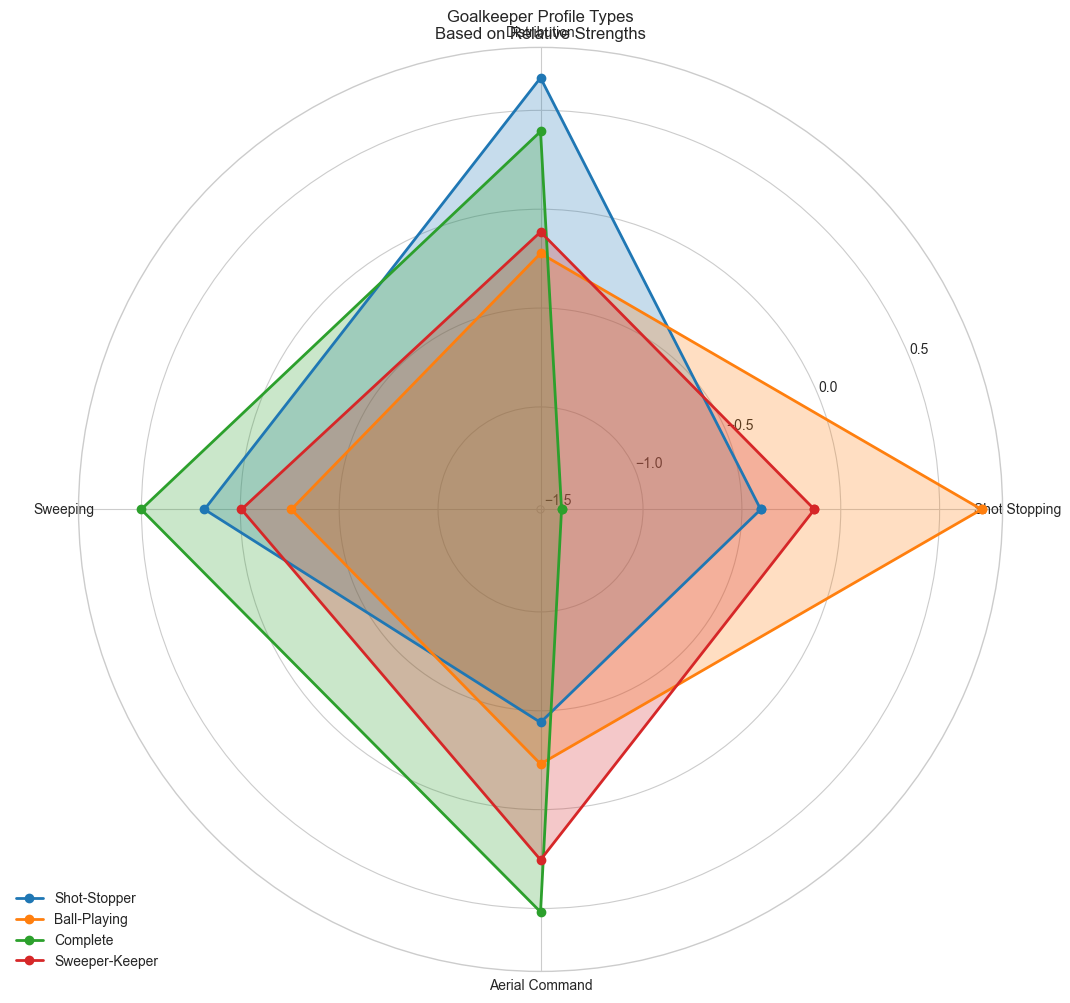

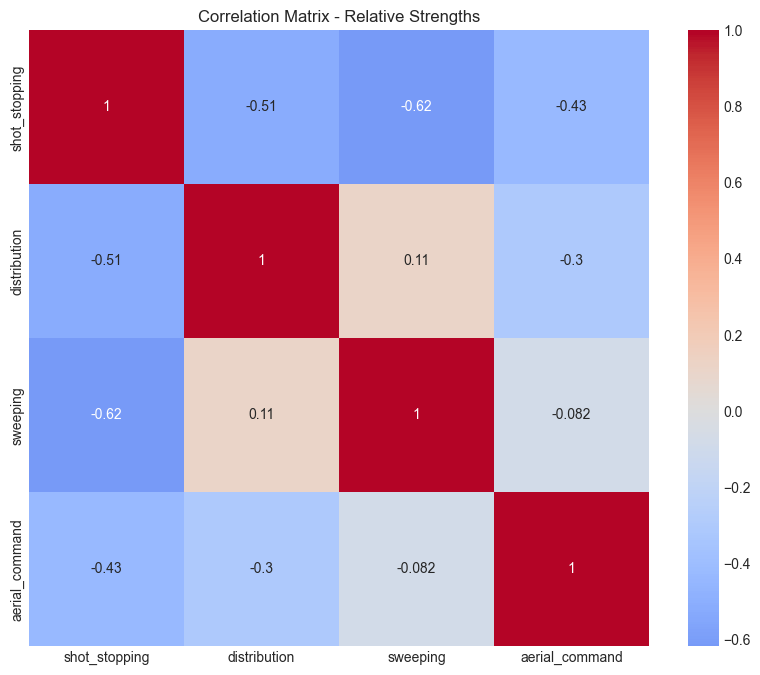

C:\Users\MOUNA\AppData\Local\Temp\ipykernel_16700\2436174658.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(profile_styles)
C:\Users\MOUNA\AppData\Local\Temp\ipykernel_16700\2436174658.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(profile_styles)
C:\Users\MOUNA\AppData\Local\Temp\ipykernel_16700\2436174658.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(profile_styles)
C:\Users\MOUNA\AppData\Local\Temp\ipykernel_16700\2436174658.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(profile_styles)


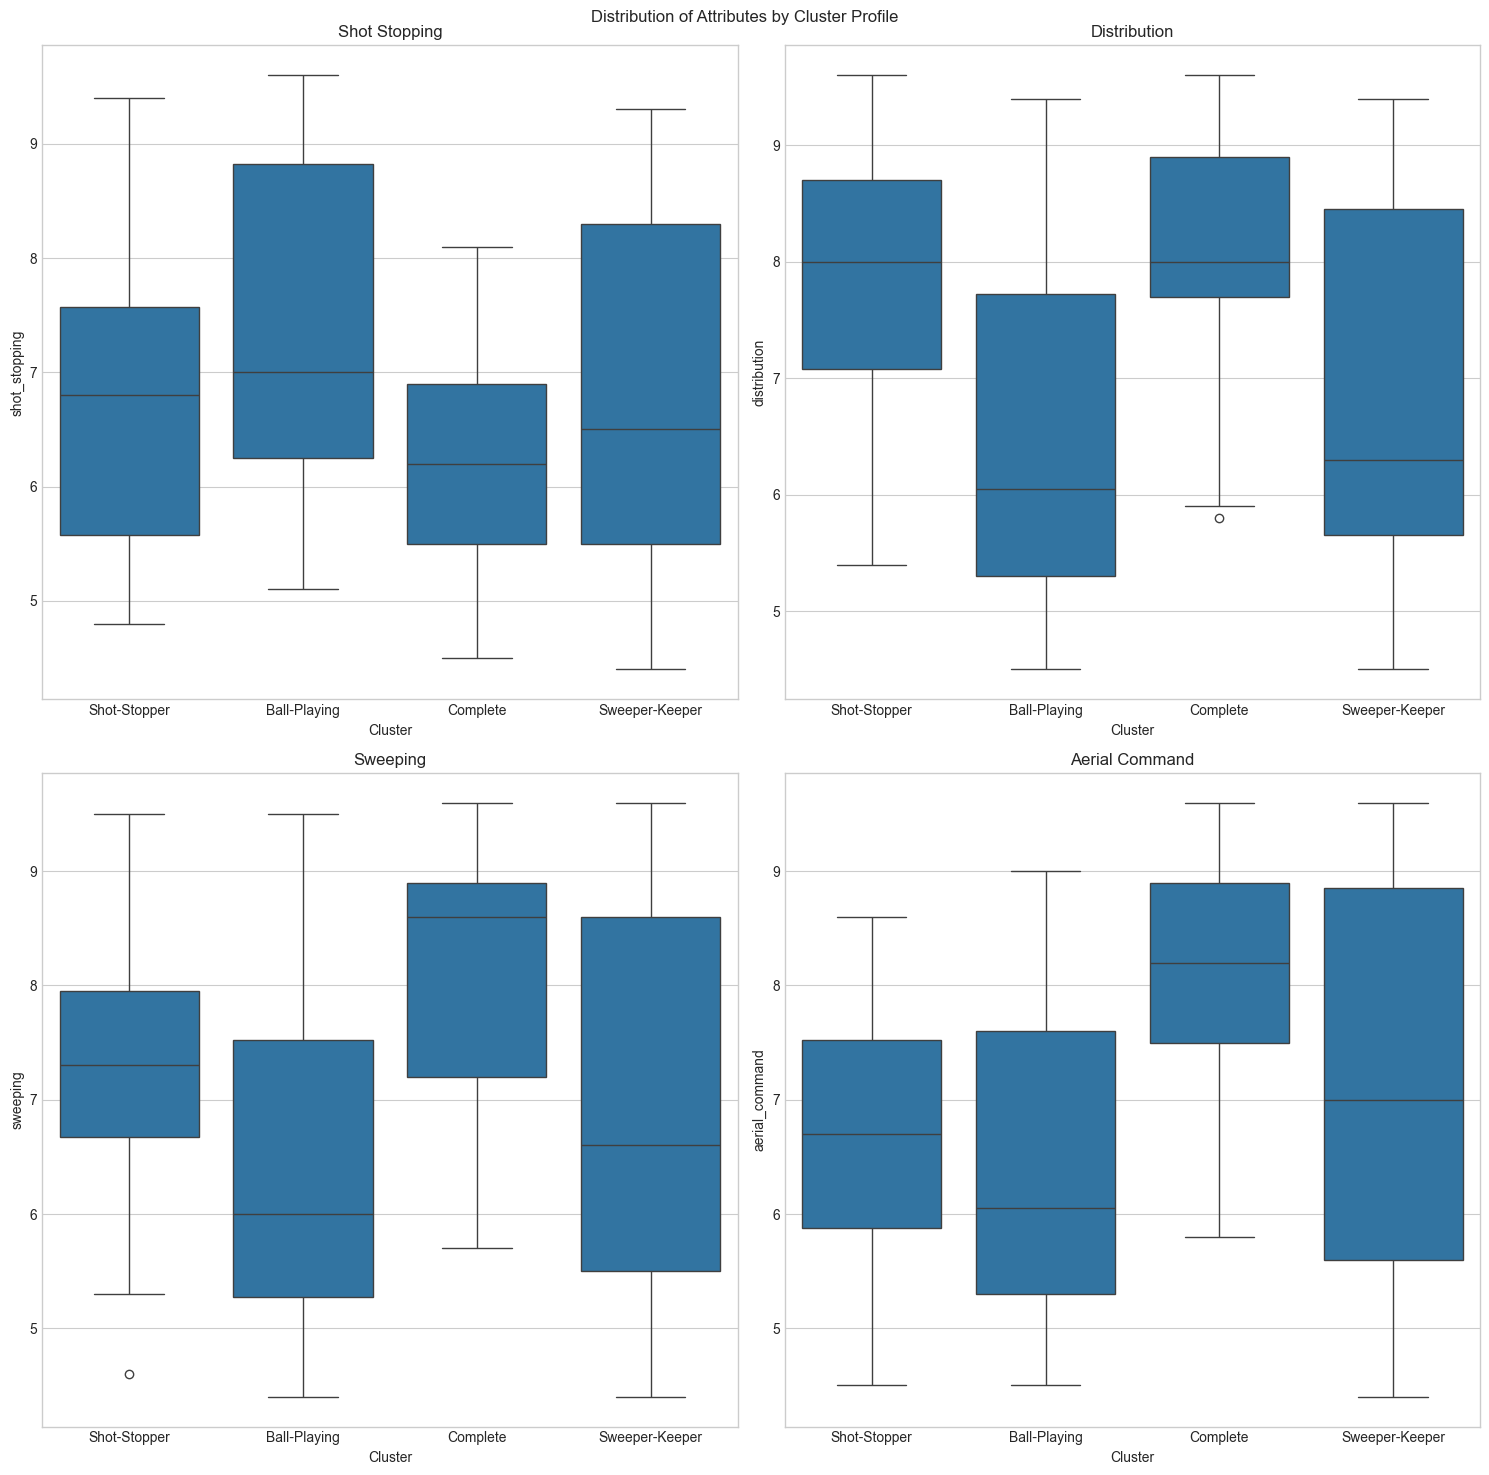

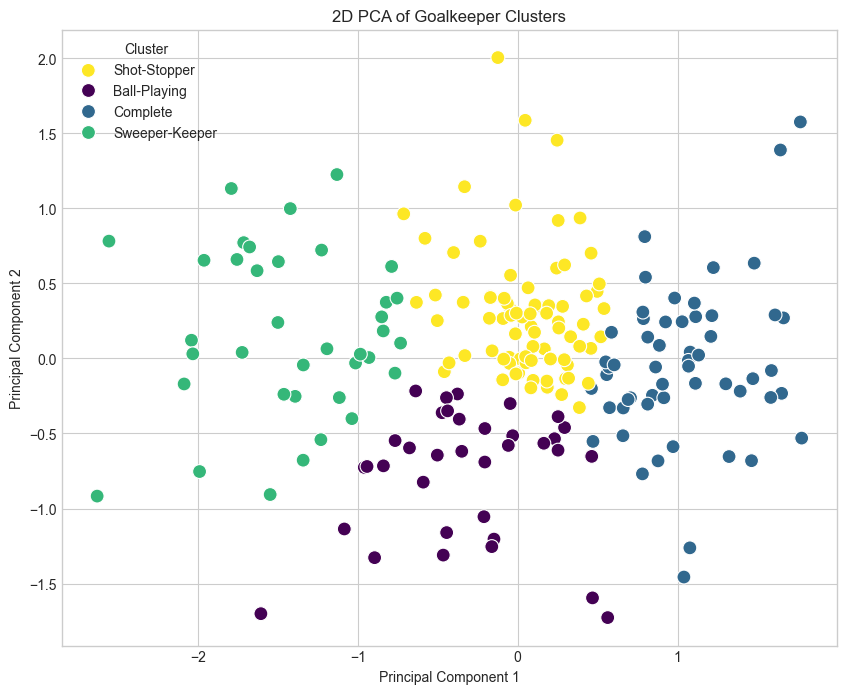


=== Cluster Summary Statistics ===

Shot-Stopper Profile Summary:
Number of goalkeepers: 36

Average absolute values:
shot_stopping     6.722222
distribution      7.791667
sweeping          7.308333
aerial_command    6.686111
dtype: float64

Standard deviations:
shot_stopping     1.195016
distribution      1.198660
sweeping          1.206974
aerial_command    1.127362
dtype: float64
--------------------------------------------------

Ball-Playing Profile Summary:
Number of goalkeepers: 56

Average absolute values:
shot_stopping     7.457143
distribution      6.521429
sweeping          6.487500
aerial_command    6.514286
dtype: float64

Standard deviations:
shot_stopping     1.426612
distribution      1.519296
sweeping          1.580456
aerial_command    1.369596
dtype: float64
--------------------------------------------------

Complete Profile Summary:
Number of goalkeepers: 37

Average absolute values:
shot_stopping     6.270270
distribution      8.075676
sweeping          8.183784


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # Replace 4 with your actual number of cores

# Set style for visualizations
plt.style.use("seaborn-v0_8-whitegrid")

def analyze_goalkeepers(data_path):
    """Main analysis function with fixed cluster mapping."""
    # Read the data
    data = pd.read_csv(data_path)
    
    # Define features for analysis
    features = ['shot_stopping', 'distribution', 'sweeping', 'aerial_command']
    
    # Calculate relative strengths (using your original method)
    goalkeeper_means = data[features].mean(axis=1)
    relative_strengths = pd.DataFrame()
    for feature in features:
        relative_strengths[feature] = data[feature] - goalkeeper_means
    
    # Perform clustering with 4 clusters (or 3 if you prefer)
    n_clusters = 4  # Change to 3 if you want to match your example exactly
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(relative_strengths)
    
    # Add cluster labels to data
    data['cluster'] = labels
    
    # Define profiles (use your original mapping)
    if n_clusters == 3:
        profile_styles = ['Shot-Stopper', 'Ball-Playing', 'Complete']
    else:
        profile_styles = ['Shot-Stopper', 'Ball-Playing', 'Complete', 'Sweeper-Keeper']
    
    # Print clusters and their members
    print("\n=== Goalkeeper Clusters ===")
    for i in range(n_clusters):
        print(f"\n{profile_styles[i]} Profile:")
        cluster_gks = data[data['cluster'] == i]
        for _, row in cluster_gks.iterrows():
            print(f"- {row['goalkeeper']} ({row['team']}) - {row['season_id']}")
        
        # Print relative strengths for this cluster
        print("\nCluster characteristics:")
        cluster_means = relative_strengths[data['cluster'] == i].mean()
        for feature in features:
            print(f"{feature}: {cluster_means[feature]:+.2f}")
        print("-" * 50)
    
    # Create radar chart
    angles = np.linspace(0, 2*np.pi, len(features), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
    for i in range(n_clusters):
        values = kmeans.cluster_centers_[i]
        values = np.concatenate((values, [values[0]]))
        ax.plot(angles, values, 'o-', linewidth=2, label=profile_styles[i])
        ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.replace('_', ' ').title() for f in features])
    ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title("Goalkeeper Profile Types\nBased on Relative Strengths")
    plt.show()

    # Create correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(relative_strengths.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix - Relative Strengths')
    plt.show()

    # Distribution of attributes by cluster
    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    fig.suptitle('Distribution of Attributes by Cluster Profile')

    for idx, feature in enumerate(features):
        ax = axes[idx//2, idx%2]
        sns.boxplot(data=data, x='cluster', y=feature, ax=ax)
        ax.set_xlabel('Cluster')
        ax.set_xticklabels(profile_styles)
        ax.set_title(feature.replace('_', ' ').title())

    plt.tight_layout()
    plt.show()

    # Perform PCA to reduce dimensionality to 2 components
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(relative_strengths)

    # Create a DataFrame with the principal components and cluster labels
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
    pca_df['cluster'] = labels

    # Plot the clusters
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=100)
    plt.title('2D PCA of Goalkeeper Clusters')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster', labels=profile_styles)
    plt.show()

    # Print summary statistics
    print("\n=== Cluster Summary Statistics ===")
    for i in range(n_clusters):
        print(f"\n{profile_styles[i]} Profile Summary:")
        cluster_data = data[data['cluster'] == i]
        print(f"Number of goalkeepers: {len(cluster_data)}")
        print("\nAverage absolute values:")
        print(cluster_data[features].mean())
        print("\nStandard deviations:")
        print(cluster_data[features].std())
        print("-" * 50)

    # Save results
    data['cluster_profile'] = data['cluster'].map({i: style for i, style in enumerate(profile_styles)})
    output_df = data[['goalkeeper', 'team', 'season_id', 'cluster_profile'] + features]
    output_df.to_csv('goalkeeper_clusters_analyzed.csv', index=False)
    
    return data, kmeans, relative_strengths

if __name__ == "__main__":
    data, kmeans, relative_strengths = analyze_goalkeepers('goalkeeper_analysis_consolidated.csv')